In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!mkdir -p Dataset/labels
!mkdir -p Dataset/images
classes = ['helmet','head','person']

In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET
from shutil import copyfile
import os
import numpy as np
import pandas as pd

In [ ]:
classes = ['helmet','head','person']

def convert_annot(size , box):
    x1 = int(box[0])
    y1 = int(box[1])
    x2 = int(box[2])
    y2 = int(box[3])

    dw = np.float32(1. / int(size[0]))
    dh = np.float32(1. / int(size[1]))

    w = x2 - x1
    h = y2 - y1
    x = x1 + (w / 2)
    y = y1 + (h / 2)

    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return [x, y, w, h]

In [28]:
!ls ../input/datasets/andrewmvd/hard-hat-detection

annotations  images


In [ ]:
def save_txt_file(img_jpg_file_name, size, img_box):
    save_file_name = '/kaggle/working/Dataset/labels/' +  img_jpg_file_name + '.txt'
    
    #file_path = open(save_file_name, "a+")
    with open(save_file_name ,'a+') as file_path:
        for box in img_box:

            cls_num = classes.index(box[0])

            new_box = convert_annot(size, box[1:])

            file_path.write(f"{cls_num} {new_box[0]} {new_box[1]} {new_box[2]} {new_box[3]}\n")

        file_path.flush()
        file_path.close()

In [ ]:
def get_xml_data(file_path, img_xml_file):
    img_path = file_path + '/' + img_xml_file + '.xml'

    tree = ET.parse(img_path)
    root = tree.getroot()

    img_name = root.find("filename").text
    img_size = root.find("size")
    img_w = int(img_size.find("width").text)
    img_h = int(img_size.find("height").text)
    img_c = int(img_size.find("depth").text)

    img_box = []
    for box in root.findall("object"):
        cls_name = box.find("name").text
        x1 = int(box.find("bndbox").find("xmin").text)
        y1 = int(box.find("bndbox").find("ymin").text)
        x2 = int(box.find("bndbox").find("xmax").text)
        y2 = int(box.find("bndbox").find("ymax").text)

        img_box.append([cls_name, x1, y1, x2, y2])

    img_jpg_file_name = img_xml_file + '.jpg'
    save_txt_file(img_xml_file, [img_w, img_h], img_box)

In [ ]:
!pwd 

In [ ]:
from tqdm import tqdm
BASE_PATH = Path("../input/datasets/andrewmvd/hard-hat-detection")

IMAGES_PATH = BASE_PATH / "images"
ANNOTATIONS_PATH = BASE_PATH / "annotations"

WORKING_PATH = Path("/kaggle/working/Dataset")

files = os.listdir("../input/datasets/andrewmvd/hard-hat-detection/annotations")
for file in tqdm(files, total=len(files)):
    file_xml = file.split(".")
    get_xml_data("../input/datasets/andrewmvd/hard-hat-detection/annotations", file_xml[0])

In [ ]:
from sklearn.model_selection import train_test_split
image_list = os.listdir(ANNOTATIONS_PATH)
train_list, test_list = train_test_split(image_list, test_size=0.2, random_state=42)
val_list, test_list = train_test_split(test_list, test_size=0.5, random_state=42)
print('total =', len(image_list))
print('train :', len(train_list))
print('val   :', len(val_list))
print('test  :', len(test_list))

In [ ]:
from pathlib import Path
from shutil import copyfile
from tqdm import tqdm

# --- DEFINE PATHS CLEANLY ---
BASE_INPUT = Path("../input/datasets/andrewmvd/hard-hat-detection")
RAW_IMAGES = BASE_INPUT / "images"

WORKING_PATH = Path("/kaggle/working/Dataset")

def copy_data(file_list, img_labels_root, imgs_source, mode):
    dataset_root = WORKING_PATH

    # Create directories
    images_path = dataset_root / 'images' / mode
    labels_path = dataset_root / 'labels' / mode
    images_path.mkdir(parents=True, exist_ok=True)
    labels_path.mkdir(parents=True, exist_ok=True)

    # Copying files
    for file in tqdm(file_list, desc=f"Copying {mode} data"):
        base_filename = Path(file).stem

        img_src_file = Path(imgs_source) / f"{base_filename}.png"
        label_src_file = Path(img_labels_root) / f"{base_filename}.txt"

        img_dest_file = images_path / f"{base_filename}.png"
        label_dest_file = labels_path / f"{base_filename}.txt"

        if not img_src_file.exists():
            print(f"Missing image: {img_src_file}")
            continue
        if not label_src_file.exists():
            print(f"Missing label: {label_src_file}")
            continue

        copyfile(img_src_file, img_dest_file)
        copyfile(label_src_file, label_dest_file)

# --- CALLS (FIXED SOURCE PATH) ---
copy_data(train_list, WORKING_PATH / "labels", RAW_IMAGES, "train")
copy_data(val_list,   WORKING_PATH / "labels", RAW_IMAGES, "val")
copy_data(test_list,  WORKING_PATH / "labels", RAW_IMAGES, "test")

In [ ]:
!git clone https://github.com/ultralytics/ultralytics
!pip install ultralytics

In [ ]:
# For example:

# "/content/drive/My Drive/helmet_dataset_YOLO/images/train/hard_hat_workers0.png"  # image
# "/content/drive/My Drive/helmet_dataset_YOLO/labels/train/hard_hat_workers0.txt  # label

import yaml

# Create configuration
config = {

   "train": "/kaggle/working/Dataset/images/train",
   "val": "/kaggle/working/Dataset/images/val",
   "test": "/kaggle/working/Dataset/images/test",
   "nc": 3,
   "names": ['helmet','head','person']
}
with open("data.yaml", "w") as file:
   yaml.dump(config, file, default_flow_style=False)

In [30]:
!cat data.yaml

names:
- helmet
- head
- person
nc: 3
test: /kaggle/working/Dataset/images/test
train: /kaggle/working/Dataset/images/train
val: /kaggle/working/Dataset/images/val


In [ ]:
# 1st run was done using this cell
!yolo task=detect mode=train \
data=data.yaml \
model=yolov8m.pt \
epochs=50 \
batch=32 \
workers=2 \
cache=True \
amp=True

In the second run i have optimized the hyperparameters for better convergence to minima.

the reasoning behind each parameter is:

batch = 40 --> kaggle's t4 GPU is of 15gbs thus utilizing atleast 14gbs by batching for faster training

workers = 2 --> load data faster

optimizer = SGD --> better generalization and more stable bounding box regression compared to adaptive optimizers  

lr0 = 0.01 --> provides a strong initial learning signal for faster convergence without causing instability  

lrf = 0.01 --> decays learning rate to 0.0001 for fine-tuning and precise localization in later epochs  

momentum = 0.937 --> accelerates convergence and reduces oscillations during gradient updates  

weight_decay = 0.0005 --> prevents overfitting by penalizing large weights and improving generalization  

cache = True --> reduces disk I/O by storing dataset in memory, leading to faster training  

amp = True --> uses mixed precision to speed up training and reduce GPU memory usage  

In [34]:
# 2nd run was done using this cell
!yolo task=detect mode=train \
data=data.yaml \
model=yolov8m.pt \
epochs=30 \
batch=40 \
workers=2 \
cache=True \
amp=True \
optimizer=SGD \
lr0=0.01 \
lrf=0.01 \
momentum=0.937 \
weight_decay=0.0005

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=40, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plo

In [35]:
!ls /kaggle/working/runs/detect/train3

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2000.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2001.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2002.jpg  weights
labels.jpg			 train_batch2.jpg


In [36]:
from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
%matplotlib inline

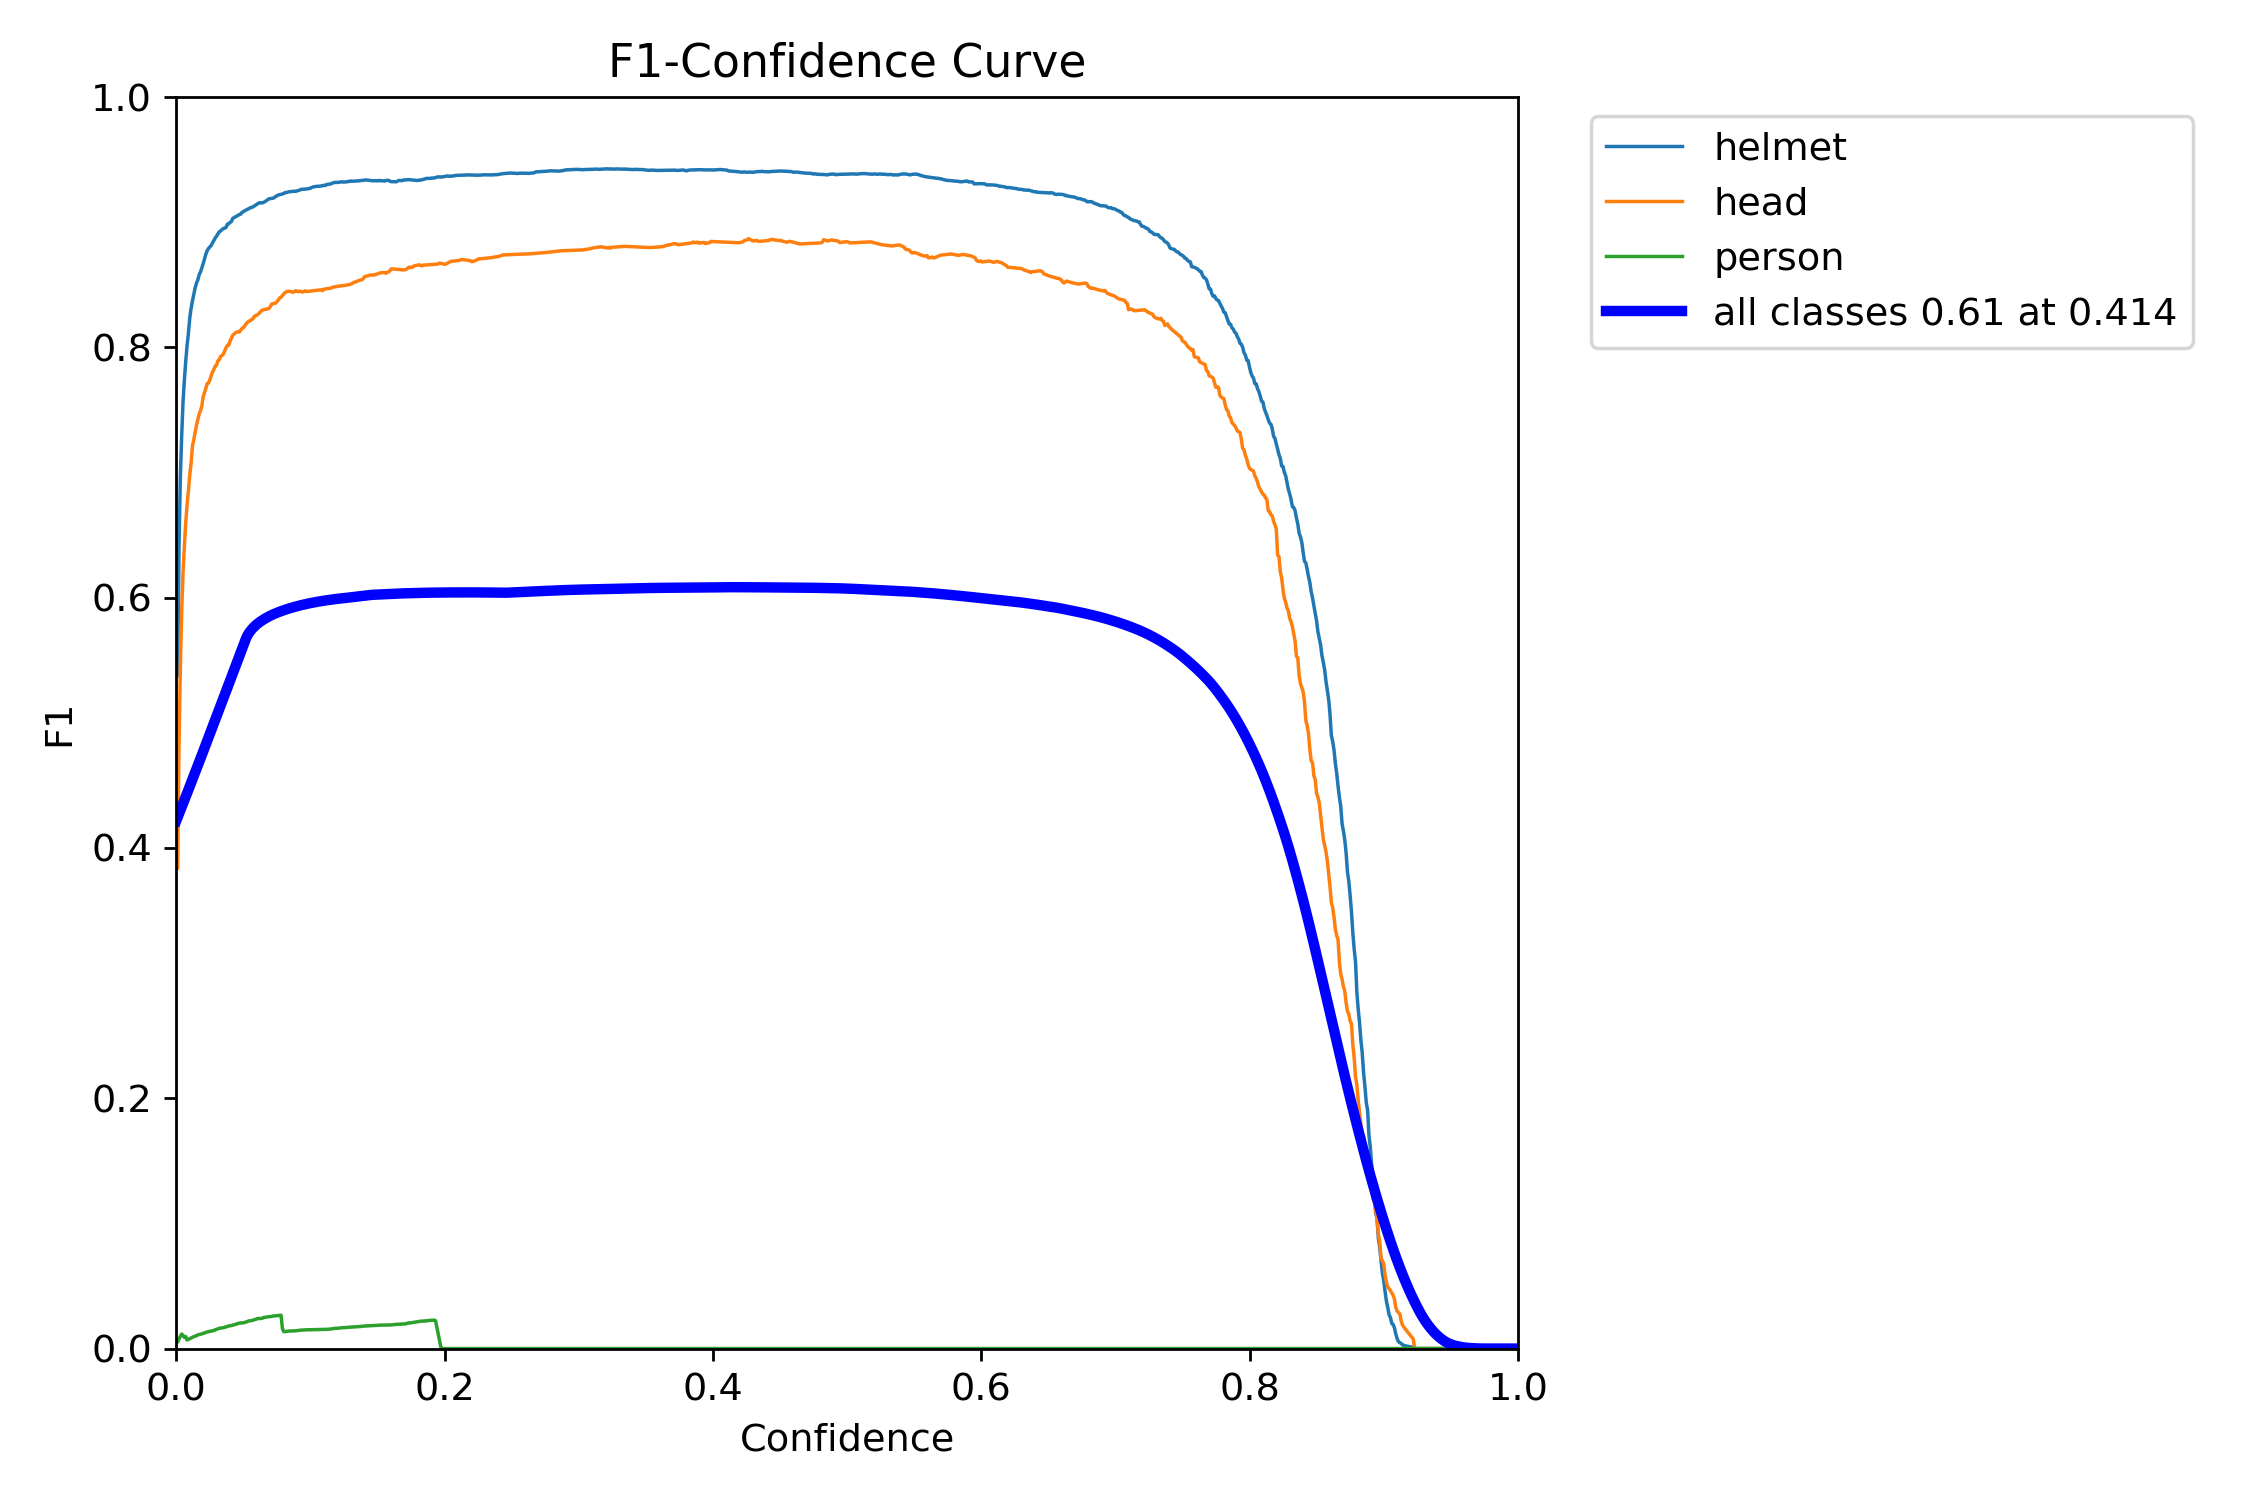

In [37]:
Image(filename='/kaggle/working/runs/detect/train3/BoxF1_curve.png', width=600)

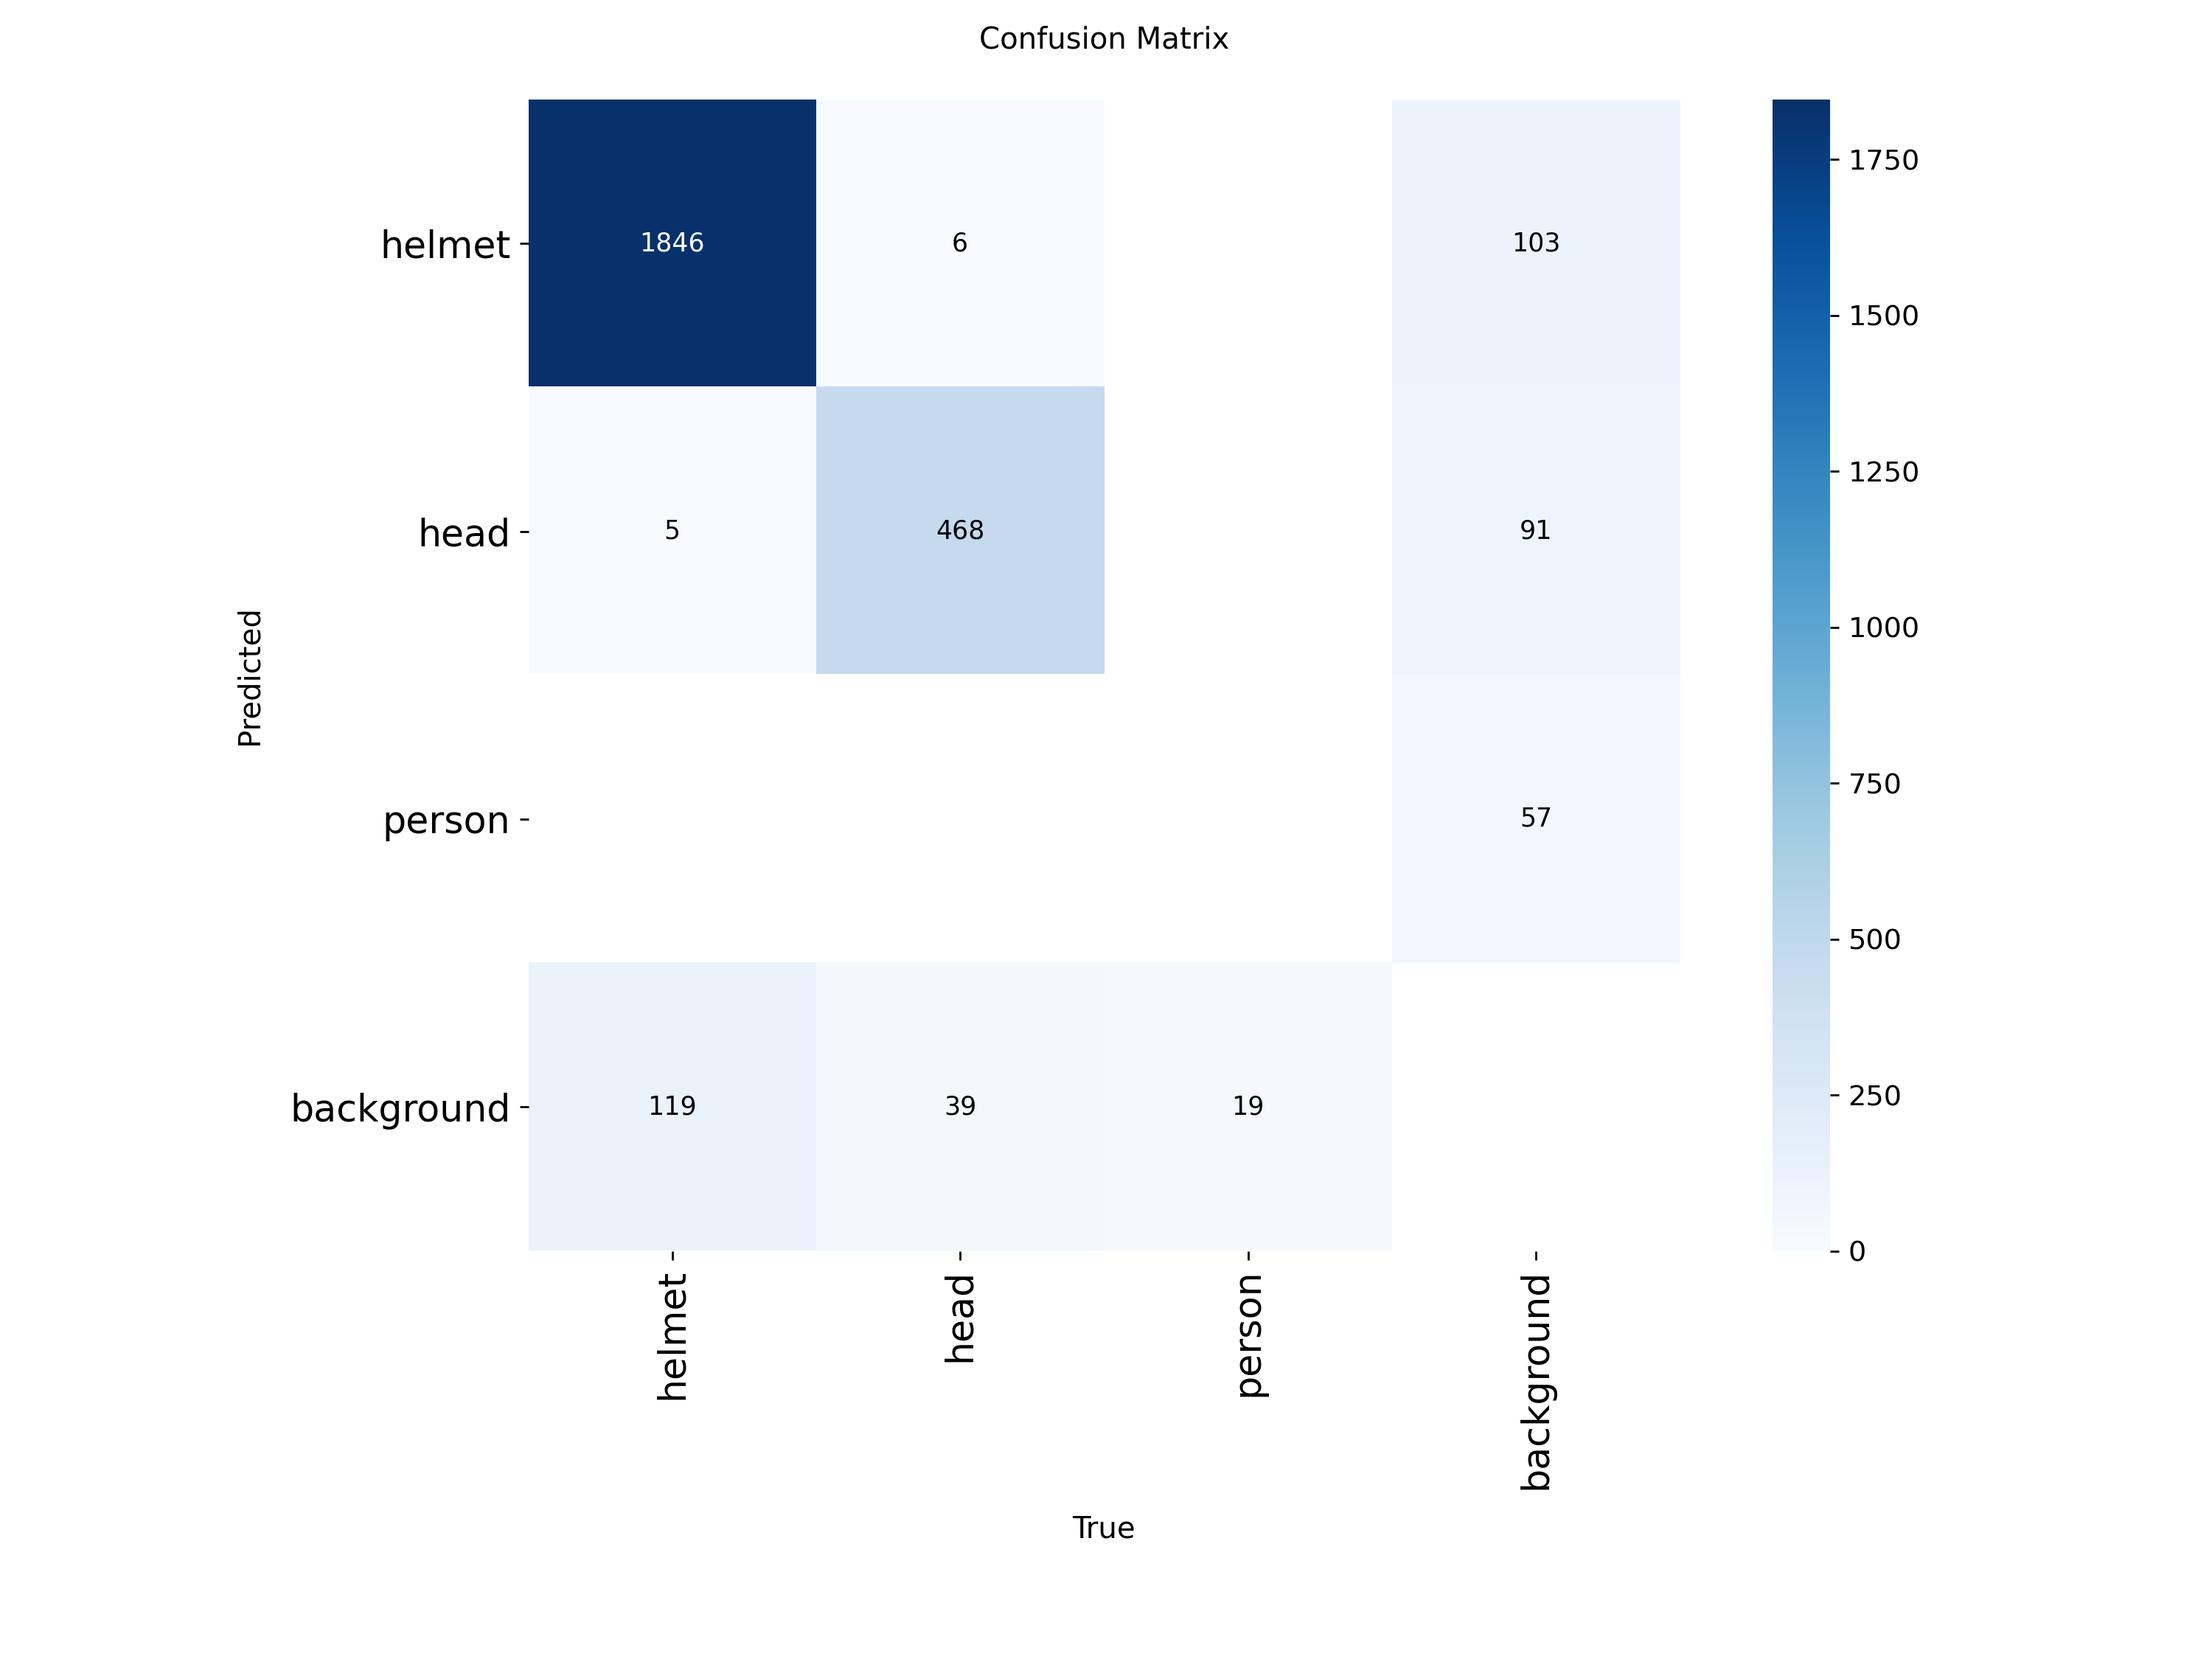

In [38]:
Image(filename='/kaggle/working/runs/detect/train3/confusion_matrix.png', width=800)

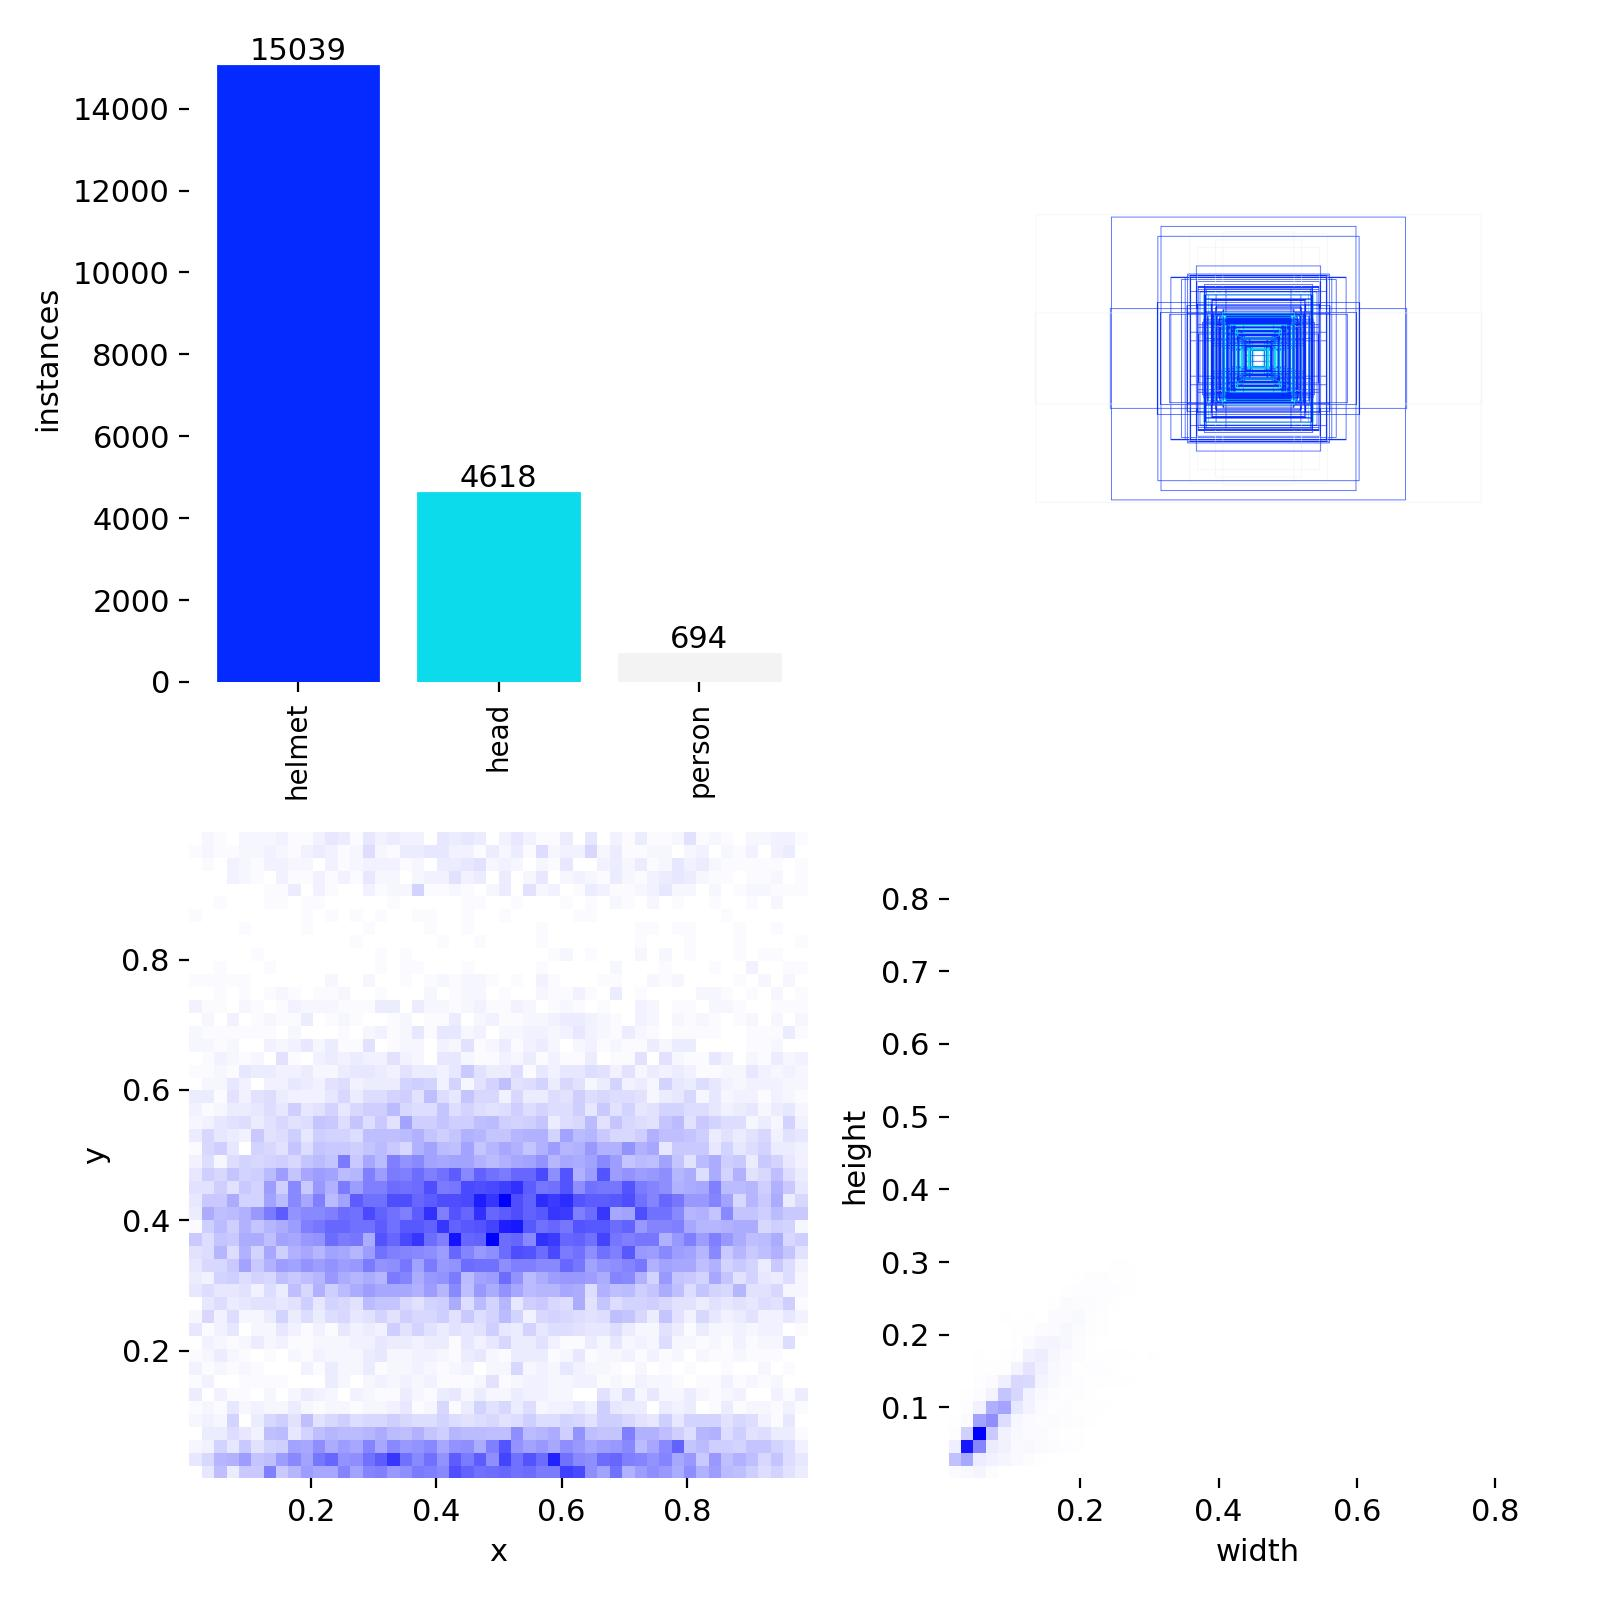

In [39]:
Image(filename='/kaggle/working/runs/detect/train3/labels.jpg', width=600)

In [41]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("/kaggle/working/runs/detect/train3/results.csv")
fig = px.line(df, x='epoch', y='metrics/mAP50(B)', title='mAP50')
fig.show()

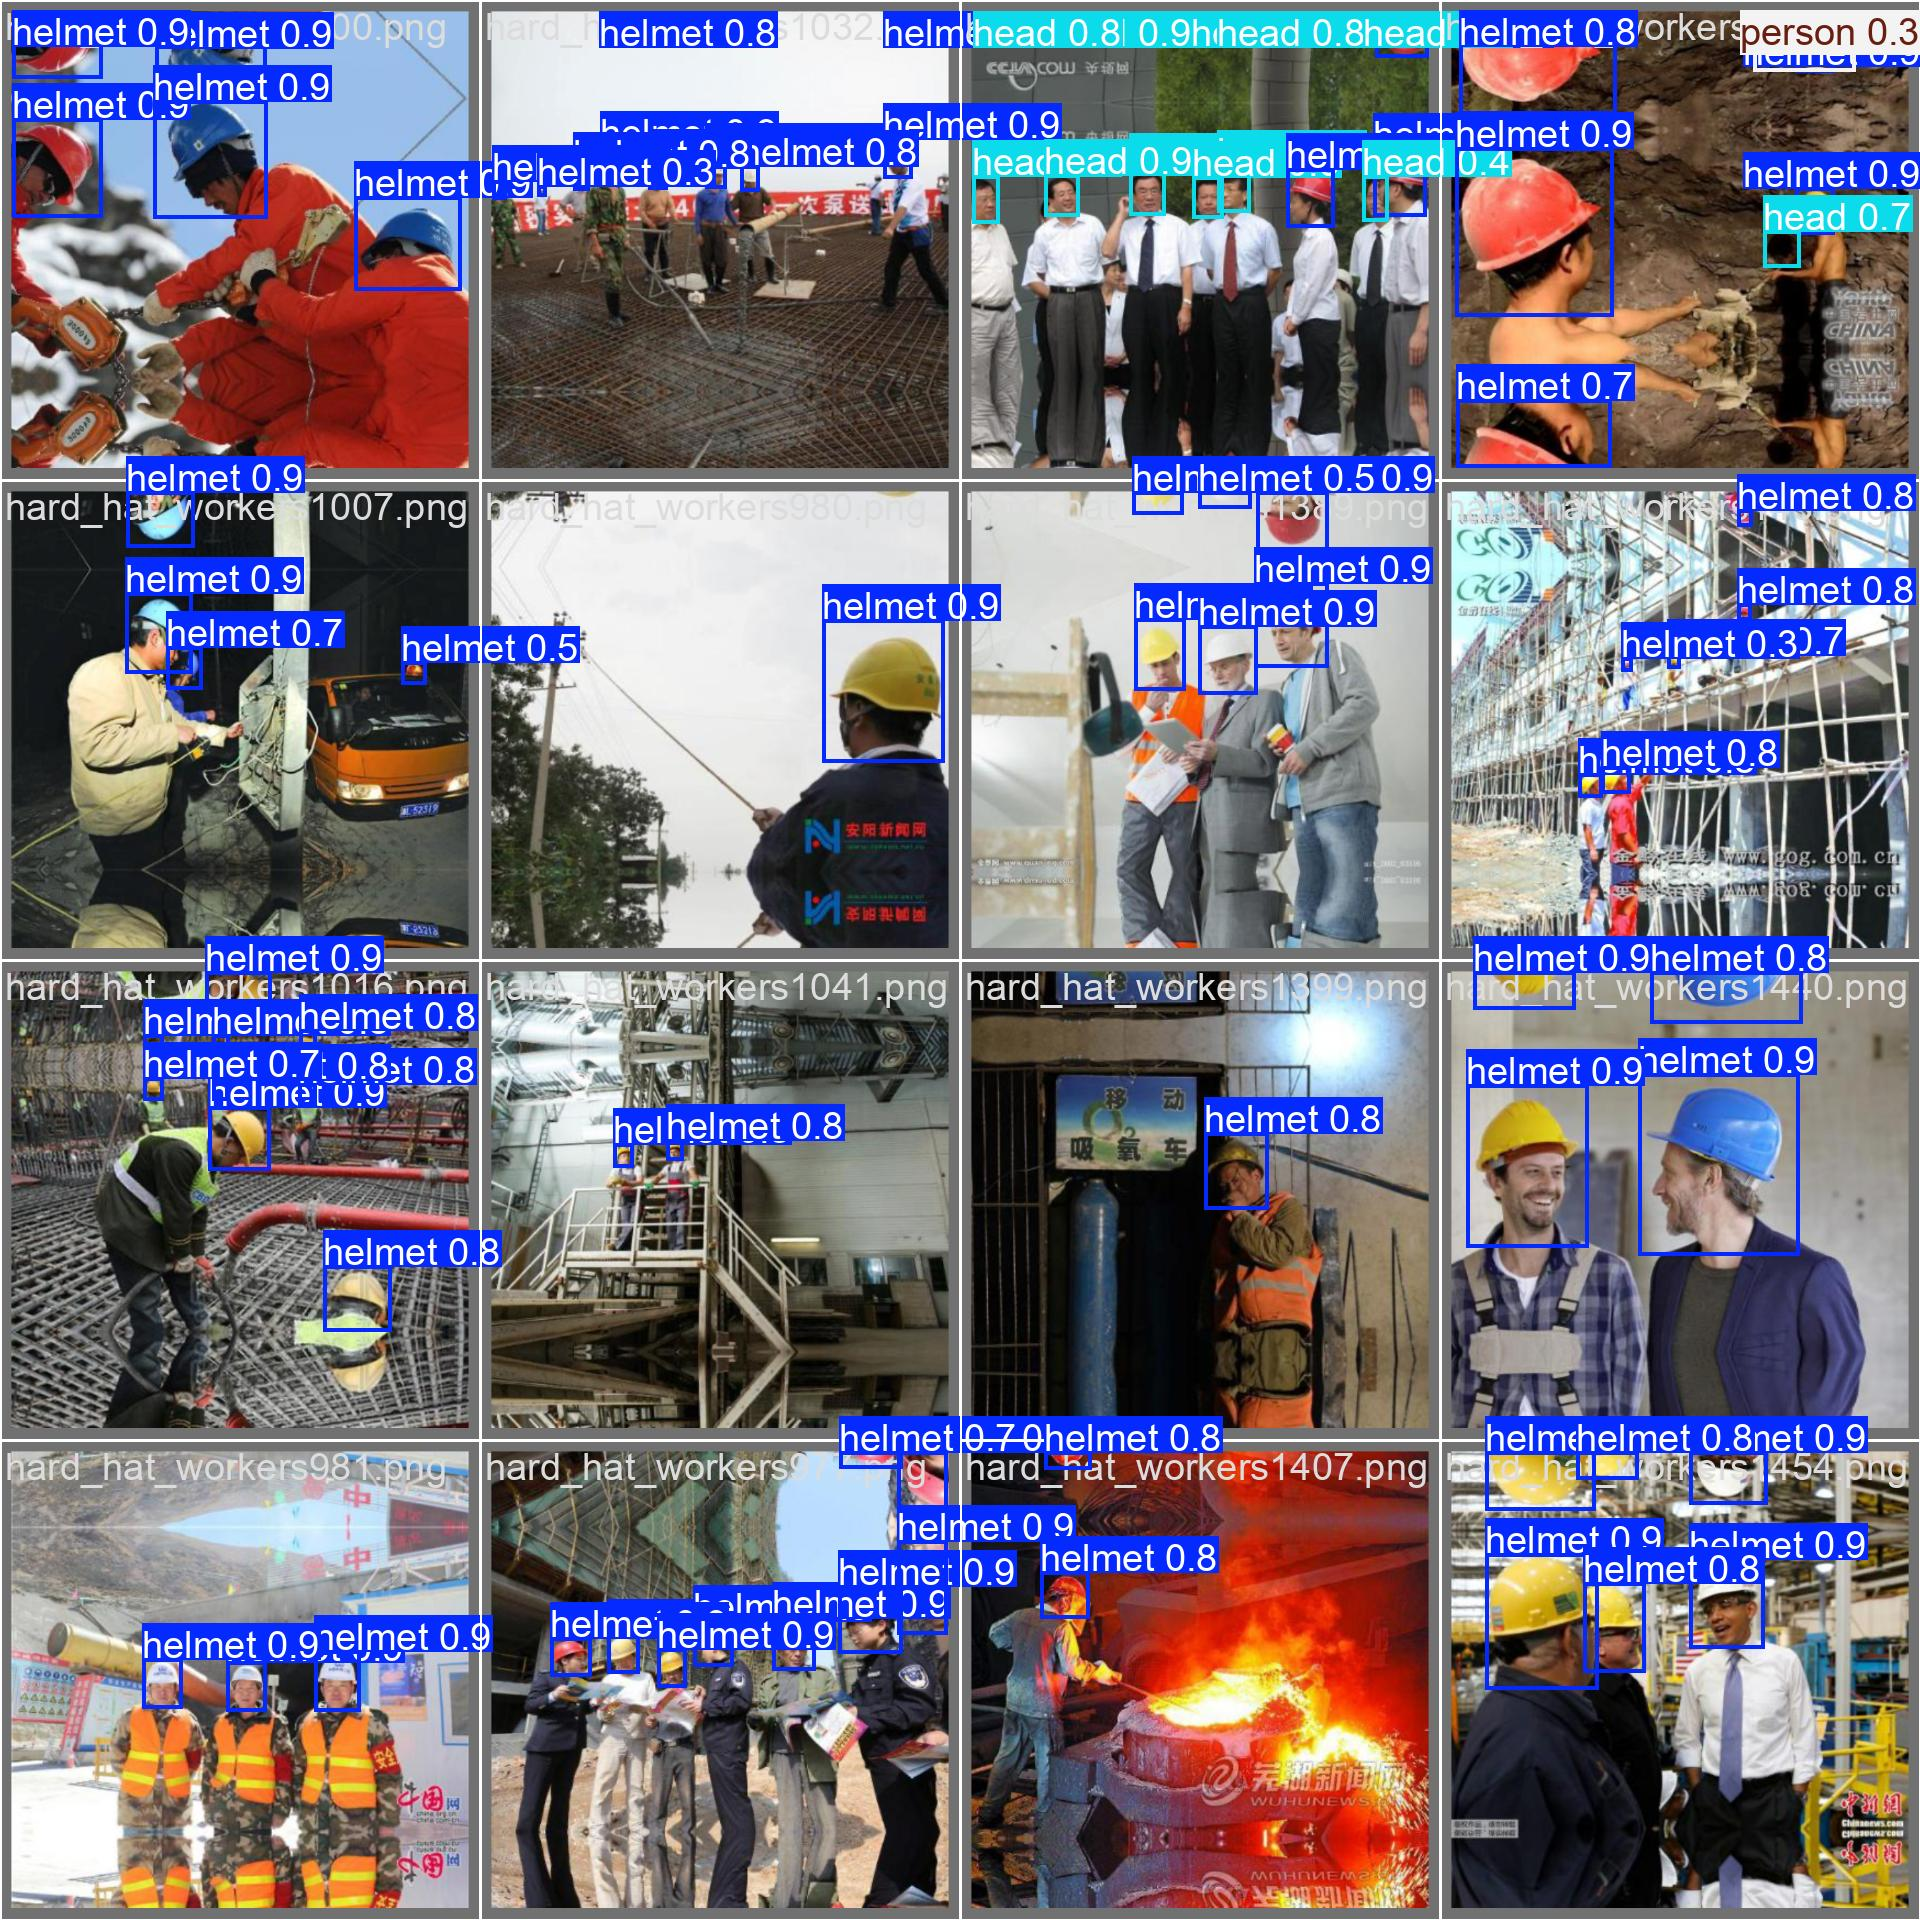

In [42]:
Image(filename='/kaggle/working/runs/detect/train3/val_batch0_pred.jpg', width=1000)

# These are the performance metrics on **Validation Dataset**.

In [43]:
!yolo task=detect mode=val model=/kaggle/working/runs/detect/train3/weights/best.pt data=data.yaml save_json = True

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2762.2±596.6 MB/s, size: 200.6 KB)
val: Scanning /kaggle/working/Dataset/labels/val.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 74.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.4it/s 13.4s0.4s
                   all        500       2502       0.61      0.607      0.627      0.414
                helmet        462       1970      0.964      0.919      0.971      0.637
                  head         81        513      0.865      0.903      0.906      0.602
                person          7         19          0          0    0.00257    0.00166
Speed: 1.4ms preprocess, 19.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving /kaggle/working/runs/detect/val/pre

# **Evaluating the Model on Test Dataset**
# By Precision & Recall Metrics

# Detection Threshold = 0.25 (Default)

In [ ]:
!yolo task=detect mode=predict model=/kaggle/working/runs/detect/train3/weights/best.pt conf=0.25 source="/kaggle/working/Dataset/images/test" save_txt=True save=True

In [45]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) for two bounding boxes in YOLO format.

    Parameters:
    - box1: Tuple (center_x, center_y, width, height)
    - box2: Tuple (center_x, center_y, width, height)

    Returns:
    - IoU: Intersection over Union
    """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Calculate coordinates of intersection rectangle
    x_left = max(x1 - w1 / 2, x2 - w2 / 2)
    y_top = max(y1 - h1 / 2, y2 - h2 / 2)
    x_right = min(x1 + w1 / 2, x2 + w2 / 2)
    y_bottom = min(y1 + h1 / 2, y2 + h2 / 2)

    # Calculate area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate areas of the individual bounding boxes
    area_box1 = w1 * h1
    area_box2 = w2 * h2

    # Calculate Union (area of box1 + area of box2 - intersection area)
    union_area = area_box1 + area_box2 - intersection_area

    # Calculate IoU
    iou = intersection_area / union_area if union_area > 0 else 0

    return iou

In [46]:
import os

def parse_yolo_label_file(lbl_src_path, img_name_txt):
    """
    Parse a YOLO label file and return a dictionary.

    Parameters:
    - lbl_src_path: Path to the directory containing YOLO label files.
    - img_name: Name of the image file (with extension).

    Returns:
    - annotations_dict: Dictionary containing parsed annotations.
    """
    annotations_dict = []

    label_file_path = os.path.join(lbl_src_path, img_name_txt)


    with open(label_file_path, 'r') as file:
        lines = file.readlines()

        for line in lines:
            values = line.strip().split()

            if len(values) >= 5:
                class_index = int(values[0])
                center_x, center_y, width, height = map(float, values[1:5])

                annotation = {
                    'class_index': class_index,
                    'center_x': center_x,
                    'center_y': center_y,
                    'width': width,
                    'height': height
                }

                annotations_dict.append(annotation)

    return annotations_dict

In [47]:
def parse_yolo_predictions_file(pred_src_path, img_name_txt):
    predictions_dict = []

    pred_file_path = os.path.join(pred_src_path, img_name_txt)

    with open(pred_file_path, 'r') as file:
        lines = file.readlines()

        for line in lines:
            values = line.strip().split()

            if len(values) >= 5:
                class_index = int(values[0])
                center_x, center_y, width, height = map(float, values[1:5])

                prediction = {
                    'class_index': class_index,
                    'center_x': center_x,
                    'center_y': center_y,
                    'width': width,
                    'height': height
                }

                predictions_dict.append(prediction)

    return predictions_dict


In [48]:
def calculate_precision_recall_per_image(targets, predictions, num_classes, iou_threshold=0.5):
    result_list = []

    for class_idx in range(num_classes):
        true_positives = 0
        false_positives = 0
        false_negatives = 0

        # Filter targets and predictions for the current class
        targets_class = [target for target in targets if target['class_index'] == class_idx]
        predictions_class = [pred for pred in predictions if pred['class_index'] == class_idx]

        for target in targets_class:
            matched_prediction = False

            for prediction in predictions_class:
                iou = calculate_iou(
                    [target['center_x'], target['center_y'], target['width'], target['height']],
                    [prediction['center_x'], prediction['center_y'], prediction['width'], prediction['height']]
                )

                if iou >= iou_threshold:
                    matched_prediction = True
                    break

            if matched_prediction:
                true_positives += 1
            else:
                false_negatives += 1

        false_positives = len(predictions_class) - true_positives

        result_list.append([true_positives, false_positives, false_negatives])

    return result_list


In [49]:
from tqdm import tqdm
list_final=  [[0,0,0],[0,0,0],[0,0,0]]

test_labels_path = "/kaggle/working/Dataset/labels/test"


pred_labels_path ="/kaggle/working/runs/detect/predict/labels"
file_names = os.listdir(pred_labels_path)

classes= ['helmet','head', 'person']

num_classes=len(classes)
iou_threshold=0.5

for input_image in tqdm(file_names, total=len(file_names)):
  annotations = parse_yolo_label_file(test_labels_path, input_image)
  predictions = parse_yolo_predictions_file(pred_labels_path, input_image)
  lists= calculate_precision_recall_per_image(annotations, predictions, num_classes, iou_threshold)
  for idx,list in enumerate(lists):
    for i in range(3):
      list_final[idx][i] += list[i]

100%|██████████| 499/499 [00:00<00:00, 6557.81it/s]


In [50]:
def calculate_precision_recall(list):
  precision_recall_dict={}
  for idx,element in enumerate(list):
    true_positives, false_positives, false_negatives = element
    precision_ = true_positives / (true_positives + false_positives + 1e-6)
    recall_ = true_positives / (true_positives + false_negatives + 1e-6)
    precision = round(precision_, 4)
    recall = round(recall_, 4)
    precision_recall_dict[f'Class {idx+1}'] = {'Precision': precision, 'Recall': recall}

  return precision_recall_dict

# saving the results and storing them in a dictionary
precision_recall_result= calculate_precision_recall(list_final)
# Print the results
print('\n')
idx=0

def caps(input_str):
    return input_str.upper()

for class_name, metrics in precision_recall_result.items():
    print(caps(classes[idx]))
    print(f"{class_name}: Precision = {metrics['Precision']:.4f}, Recall = {metrics['Recall']:.4f}")
    print()
    idx+=1



HELMET
Class 1: Precision = 0.9203, Recall = 0.9335

HEAD
Class 2: Precision = 0.9036, Recall = 0.9174

PERSON
Class 3: Precision = 0.0000, Recall = 0.0000



In [51]:
!ls ../../kaggle/working/runs/detect/train3/weights

best.pt  last.pt


In [ ]:
from IPython.display import FileLink
FileLink('/kaggle/working/runs/detect/train3/weights/best.pt')

In [ ]:
import os

print(os.listdir('/kaggle/working/runs/detect/train3/weights/best.pt'))